In [1]:
# Imports
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import random
import numpy as np
import os
import pandas as pd
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision Training
from tqdm import tqdm # Barra de progresso
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
def set_seed(seed):
    """
    Sets random seeds for reproducibility across different libraries and environments.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # Garante operações baseadas em hash consistentes
    torch.manual_seed(seed) # seed da CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)       # Define seed na GPU atual
        torch.cuda.manual_seed_all(seed)   # Define seed para todas as GPUs
        # Garante comporamento deterministico para backend cuDNN (para operações convolucionais)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
            torch.use_deterministic_algorithms(True)
        except RuntimeError as e:
            print(f"Warning: Could not set deterministic algorithms. Error: {e}")
            print("Some PyTorch operations might still be non-deterministic. Consider reviewing PyTorch version and operation types.")
set_seed(42)

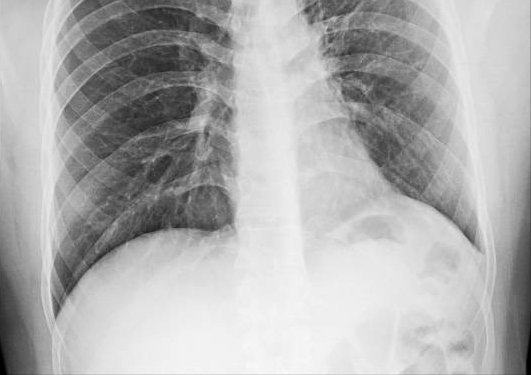

In [4]:
caminho_imagem = "D:/iniciacao_cientifica/untreated_images/images/Entry_ROI/img525.png"
imagem = Image.open(caminho_imagem)
display(imagem)

In [5]:
# Defnição do diretório das imagens e do CSV
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\iniciacao-cientifica\data\Data_Entry_Undergrad_Final.csv"
# Lendo os arquivos CSV
all_xray_df = pd.read_csv(csv_path)

# Mapeando caminhos
all_image_paths_map = {}
# Utilização do glob para encontrar todas as imagens
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # Chave == filename para ser o mesmo que os Image Labels
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Depurar imagens não-encontradas
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"\nWarning: {unmapped_images_count} images in the CSV could not be mapped to a file path.")
    print(f"Removing {unmapped_images_count} unmapped entries...")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Remaining rows: {len(all_xray_df)}")
else:
    print("\nAll CSV entries successfully mapped to image file paths.")

# Análise de dados ao nivel do paciente
print("\n--- Patient Data Analysis ---")
if 'Patient ID' in all_xray_df.columns:
    num_unique_patients = all_xray_df['Patient ID'].nunique()
    print(f"Total unique patients found: {num_unique_patients}")
    
    print("\nImages per patient summary:")

    print(all_xray_df['Patient ID'].value_counts().describe())
else:
    print("Warning: 'Patient ID' column not found in the CSV. Cannot perform patient-level analysis.")

print("\nSample of the prepared DataFrame:")
print(all_xray_df[['Patient ID', 'Image Label', 'Finding Labels', 'path']].sample(3))

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072

All CSV entries successfully mapped to image file paths.

--- Patient Data Analysis ---
Total unique patients found: 587

Images per patient summary:
count    587.000000
mean       1.826235
std        2.487606
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       18.000000
Name: count, dtype: float64

Sample of the prepared DataFrame:
      Patient ID  Image Label Finding Labels  \
992          567   img993.png             TB   
746          511   img747.png             TB   
1066         587  img1067.png             TB   

                                                   path  
992   D:\iniciacao_cientifica\untreated_images\image...  
746   D:\iniciacao_cientifica\untreated_images\image...  
1066  D:\iniciacao_cientifica\untreated_images\image...  


In [6]:
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI"
csv_path = r"D:\iniciacao_cientifica\iniciacao-cientifica\data\Data_Entry_Undergrad_Final.csv"

all_xray_df = pd.read_csv(csv_path)

# Mapear caminhos para as imagens 
all_image_paths_map = {os.path.basename(p): p for p in glob(os.path.join(image_entry_roi_dir, '*.png'))}
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Limpar imagens nao-mapeadas
unmapped_count = all_xray_df['path'].isnull().sum()
if unmapped_count > 0:
    print(f"Warning: Dropping {unmapped_count} rows from the CSV that did not have a matching image file.")
    all_xray_df.dropna(subset=['path'], inplace=True)

all_xray_df.reset_index(drop=True, inplace=True)

# Criar a coluna binária 'is_tb' para identificar imagens com TB
mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

print("--- Data Loading and Preparation Summary ---")
print(f"Total entries in CSV: {pd.read_csv(csv_path).shape[0]}")
print(f"Image files found in directory: {len(all_image_paths_map)}")
print(f"Final number of usable images after mapping: {len(all_xray_df)}")
print(f"Total unique patients: {all_xray_df['Patient ID'].nunique()}")
print("-" * 40)


# Divisão de dados para treino, validação e teste

print("\n--- Starting Patient-Aware Data Splitting ---")
# Criar Dataframe com uma linha por paciente para gerar splits
# Label do paciente é '1' se tem este tem qualquer imagem 'TB'
patient_df = all_xray_df.groupby('Patient ID').agg(
    is_tb=('is_tb', 'max') # 'max' garante que se qualquer imagem do paciente é 1, o label do paciente também é 1
).reset_index()

print(f"Created a patient-level DataFrame with {len(patient_df)} unique patients.")
print("Patient-level label distribution before splitting:")
print(patient_df['is_tb'].value_counts())

# Split pacientes nos datasets de treino (80%) e validação (20% para validação e testes)
# Stratify usando label 'is_tb' para manter distribuição
train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df['is_tb']
)

# Split nos pacientes de validação para seus respectivos datasets
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5, # 50% dos 20% do dataset temporário == 10% do total
    random_state=42,
    stratify=temp_patients['is_tb']
)

# Criar lista de ID pacientes para cada dataset
train_patient_ids = train_patients['Patient ID'].tolist()
val_patient_ids = val_patients['Patient ID'].tolist()
test_patient_ids = test_patients['Patient ID'].tolist()

# Criar DataFrames finais filtrando o DataFrame original
train_df = all_xray_df[all_xray_df['Patient ID'].isin(train_patient_ids)].copy()
val_df = all_xray_df[all_xray_df['Patient ID'].isin(val_patient_ids)].copy()
test_df = all_xray_df[all_xray_df['Patient ID'].isin(test_patient_ids)].copy()


# Verificação e Resumo
print("\n--- Verification ---")
# Checkagem final para ver se não existe overlap (mistura) de pacientes nos datasets
train_ids_set = set(train_df['Patient ID'])
val_ids_set = set(val_df['Patient ID'])
test_ids_set = set(test_df['Patient ID'])

assert len(train_ids_set.intersection(val_ids_set)) == 0, "FATAL: Patient overlap found between train and validation sets!"
assert len(train_ids_set.intersection(test_ids_set)) == 0, "FATAL: Patient overlap found between train and test sets!"
assert len(val_ids_set.intersection(test_ids_set)) == 0, "FATAL: Patient overlap found between validation and test sets!"
print("Verification successful: No patient overlap between train, validation, and test sets.")

print("\n--- Data Split Summary ---")
print(f"Total Patients: {len(patient_df)}")
print(f"Training Patients: {len(train_patient_ids)} | Validation Patients: {len(val_patient_ids)} | Test Patients: {len(test_patient_ids)}")
print("-" * 40)
print(f"Total Images: {len(all_xray_df)}")
print(f"Training Images: {len(train_df)} | Validation Images: {len(val_df)} | Test Images: {len(test_df)}")

print("\nTraining Set Label Distribution (Images):")
print(train_df['is_tb'].value_counts())
print("\nValidation Set Label Distribution (Images):")
print(val_df['is_tb'].value_counts())
print("\nTest Set Label Distribution (Images):")
print(test_df['is_tb'].value_counts())

--- Data Loading and Preparation Summary ---
Total entries in CSV: 1072
Image files found in directory: 1072
Final number of usable images after mapping: 1072
Total unique patients: 587
----------------------------------------

--- Starting Patient-Aware Data Splitting ---
Created a patient-level DataFrame with 587 unique patients.
Patient-level label distribution before splitting:
is_tb
0    439
1    148
Name: count, dtype: int64

--- Verification ---
Verification successful: No patient overlap between train, validation, and test sets.

--- Data Split Summary ---
Total Patients: 587
Training Patients: 469 | Validation Patients: 59 | Test Patients: 59
----------------------------------------
Total Images: 1072
Training Images: 857 | Validation Images: 107 | Test Images: 108

Training Set Label Distribution (Images):
is_tb
1    506
0    351
Name: count, dtype: int64

Validation Set Label Distribution (Images):
is_tb
1    63
0    44
Name: count, dtype: int64

Test Set Label Distribution 

--- USING UNBALANCED TRAINING SET ---
Original (and final) training set image counts:
is_tb
1    506
0    351
Name: count, dtype: int64

--- Final Dataset Counts (UNBALANCED EXPERIMENT) ---
Unbalanced Training Set Counts:
is_tb
1    506
0    351
Name: count, dtype: int64

Validation Set Counts (Unchanged):
is_tb
1    63
0    44
Name: count, dtype: int64

Test Set Counts (Unchanged):
is_tb
1    64
0    44
Name: count, dtype: int64


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_14988\1091303975.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")


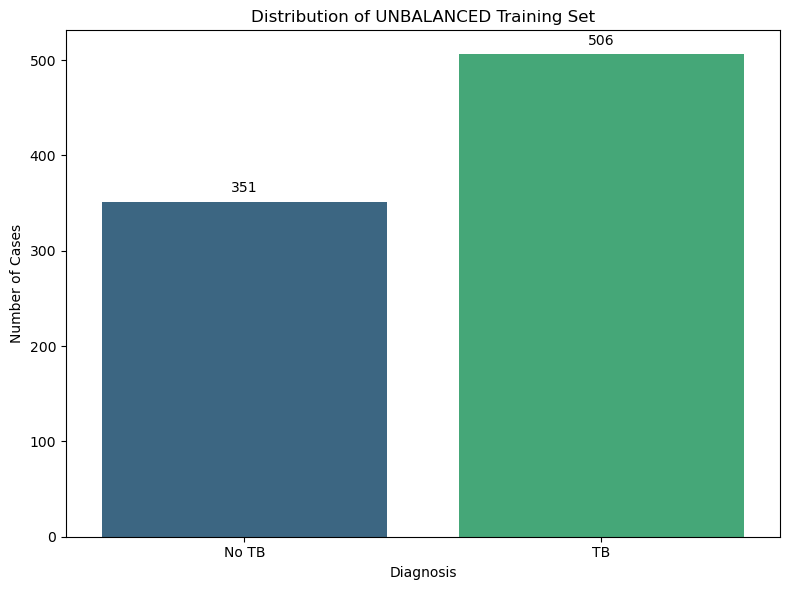


Sample of the UNBALANCED Training DataFrame to be used:


,Patient ID,Image Label,Finding Labels,path,is_tb
321,322,img322.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
445,441,img446.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
375,376,img376.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
715,504,img716.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
112,113,img113.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0


In [7]:
print("--- USING UNBALANCED TRAINING SET ---")
print("Original (and final) training set image counts:")
print(train_df['is_tb'].value_counts())

train_df_unbalanced = train_df.copy() # Use the original, unbalanced training DataFrame

print("\n--- Final Dataset Counts (UNBALANCED EXPERIMENT) ---")
print("Unbalanced Training Set Counts:")
print(train_df_unbalanced['is_tb'].value_counts()) # This will show the natural imbalance
print("\nValidation Set Counts (Unchanged):")
print(val_df['is_tb'].value_counts())
print("\nTest Set Counts (Unchanged):")
print(test_df['is_tb'].value_counts())

# Generate a plot to visualize the IMBALANCE
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
unbalanced_counts = train_df_unbalanced['is_tb'].value_counts()
tb_categories = ['No TB', 'TB']
tb_values = [unbalanced_counts.get(0, 0), unbalanced_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")
ax1.set_title('Distribution of UNBALANCED Training Set')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Add exact counts on top of bars
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

# Sample of the final training DataFrame to be used
print("\nSample of the UNBALANCED Training DataFrame to be used:")
display(train_df_unbalanced[['Patient ID', 'Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

# IMPORTANT: From this point forward, ensure you are using 'train_df_unbalanced' 
# where you were previously using 'train_df_balanced'.

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_14988\3807832996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)


Visualizing class distributions for the final train, validation, and test sets:


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_14988\3807832996.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_14988\3807832996.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)


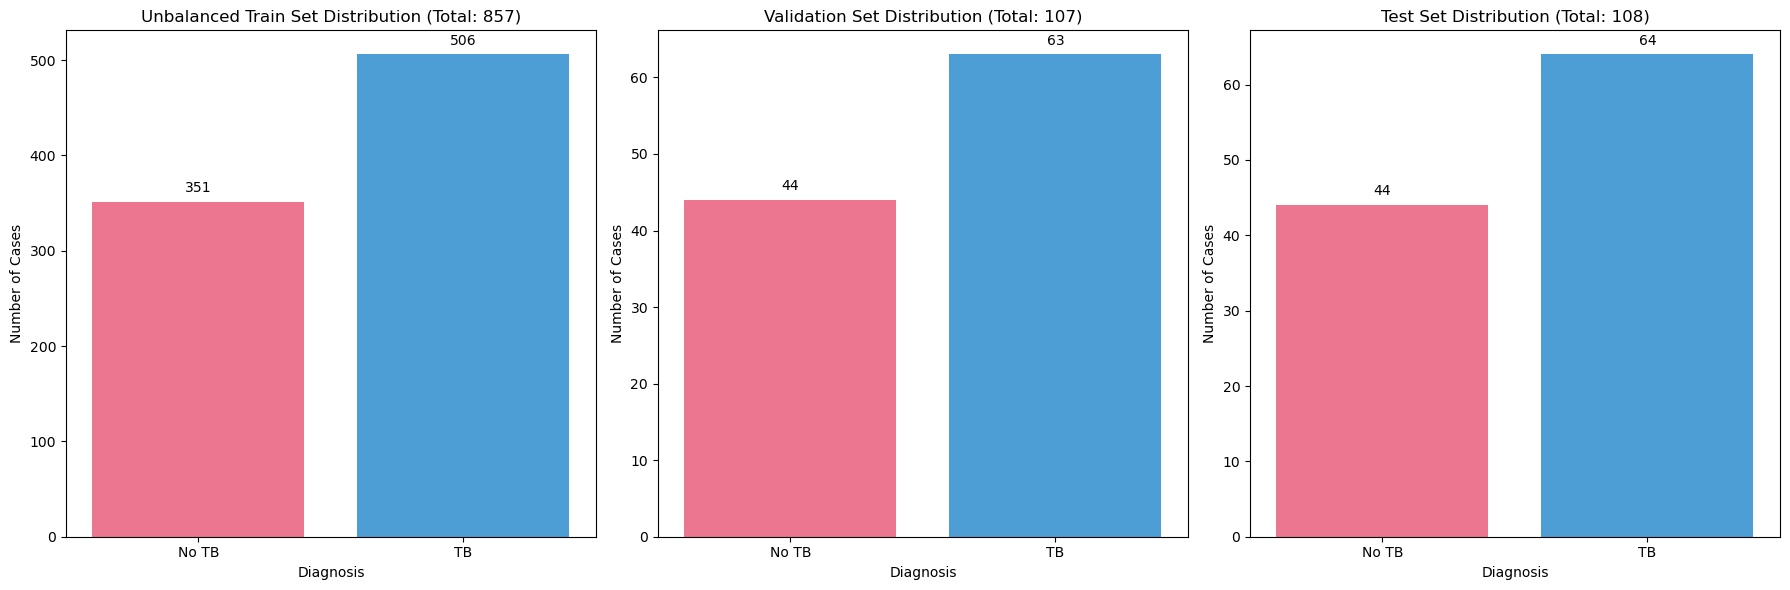

In [8]:
print("Visualizing class distributions for the final train, validation, and test sets:")
# Criar figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Ajustar tamanho da figura
tb_categories = ['No TB', 'TB']
colors = ['#FF6384', '#36A2EB']

train_counts = train_df_unbalanced['is_tb'].value_counts().sort_index()
train_values = [train_counts.get(0, 0), train_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
axes[0].set_title(f'Unbalanced Train Set Distribution (Total: {len(train_df_unbalanced)})')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Diagnosis')

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

val_counts = val_df['is_tb'].value_counts().sort_index()
val_values = [val_counts.get(0, 0), val_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_df)})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_xlabel('Diagnosis')
# Contagem exata
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

test_counts = test_df['is_tb'].value_counts().sort_index()
test_values = [test_counts.get(0, 0), test_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)
axes[2].set_title(f'Test Set Distribution (Total: {len(test_df)})')
axes[2].set_ylabel('Number of Cases')
axes[2].set_xlabel('Diagnosis')
# Contagem exata
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()  
plt.show() 

In [9]:
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.dataframe = self._validate_image_paths()
        
    def _validate_image_paths(self):
        initial_count = len(self.dataframe)
        valid_paths_mask = self.dataframe['path'].apply(os.path.exists)
        invalid_paths_df = self.dataframe.loc[~valid_paths_mask]
        if not invalid_paths_df.empty:
            print(f"Warning: {len(invalid_paths_df)} images not found. Examples:")
            for img_path in invalid_paths_df['path'].head(5):
                print(f"  - {img_path}")
        validated_dataframe = self.dataframe[valid_paths_mask].reset_index(drop=True)
        if len(validated_dataframe) == 0:
            raise ValueError("No valid images found in the DataFrame after path validation.")
        if len(validated_dataframe) < initial_count:
            print(f"Dataset reduced from {initial_count} to {len(validated_dataframe)} valid images.")
        return validated_dataframe
        
    def __len__(self):
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        try:
            image = Image.open(img_path).convert('RGB')
            label = self.dataframe.iloc[idx]['is_tb']
            label = torch.tensor(label, dtype=torch.float32)
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            raise RuntimeError(f"Error loading or processing image {img_path} at index {idx}: {e}") from e

def compute_dataset_stats(loader):
    total_pixels = torch.zeros(3)
    sum_pixel_values = torch.zeros(3)
    sum_squared_pixel_values = torch.zeros(3)
    print("Calculating dataset mean and std...")
    for i, (images, _) in enumerate(tqdm(loader, desc="Calculating Stats")):
        if images is None or images.numel() == 0 or images.dim() != 4:
            continue
        images_flat = images.view(images.size(0), images.size(1), -1)
        sum_pixel_values += images_flat.sum(dim=[0, 2])
        sum_squared_pixel_values += (images_flat ** 2).sum(dim=[0, 2])
        total_pixels += images_flat.size(0) * images_flat.size(2)
    if total_pixels.sum() == 0:
        raise ValueError("No valid image data processed to compute statistics.")
    mean = sum_pixel_values / total_pixels
    variance = (sum_squared_pixel_values / total_pixels) - (mean ** 2)
    std = torch.sqrt(torch.clamp(variance, min=0.0))
    return mean, std

# --- MODIFIED: Check for and use 'train_df_unbalanced' ---
if 'train_df_unbalanced' not in locals():
    print("Error: 'train_df_unbalanced' not found. Please ensure the cells creating it were run.")
    raise NameError("'train_df_unbalanced' not found.")
    
# Definir transformações mínimas
temp_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Criar dataset temporario e DataLoader temporário
try:
    print(f"\nAttempting to compute stats on {len(train_df_unbalanced)} images in train_df_unbalanced.")
    # --- MODIFIED: Use train_df_unbalanced ---
    temp_dataset = ChestXRayDataset(dataframe=train_df_unbalanced, transform=temp_transforms)
    
    temp_loader = DataLoader(
        temp_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0
    )
    
    # Calcular média e desvio padrão para o dataset DESBALANCEADO
    computed_mean, computed_std = compute_dataset_stats(temp_loader)
    
    # Print with formatting for clarity
    print("\n--- Computed Dataset Statistics (from UNBALANCED training set) ---")
    print(f"Mean (RGB channel-wise):     {computed_mean.tolist()}")
    print(f"Standard Dev (RGB channel-wise): {computed_std.tolist()}")
    print("------------------------------------------------------------------")
    
    # Armazenar variaveis
    global_dataset_mean = computed_mean
    global_dataset_std = computed_std
except Exception as e:
    print(f"An error occurred during dataset stats computation: {e}")


Attempting to compute stats on 857 images in train_df_unbalanced.
Calculating dataset mean and std...


Calculating Stats: 100%|██████████| 27/27 [01:22<00:00,  3.06s/it]


--- Computed Dataset Statistics (from UNBALANCED training set) ---
Mean (RGB channel-wise):     [0.5977386236190796, 0.5977386236190796, 0.5977386236190796]
Standard Dev (RGB channel-wise): [0.25810036063194275, 0.25810036063194275, 0.25810036063194275]
------------------------------------------------------------------


In [10]:
print(f"Using computed mean for normalization: {global_dataset_mean.tolist()}")
print(f"Using computed std for normalization: {global_dataset_std.tolist()}")

# 1. Transforms de treinamento (com Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.RandomHorizontalFlip(),        # Randomly flip images horizontally
    transforms.RandomRotation(10),            # Randomly rotate images by +/- 10 degrees
    transforms.ColorJitter(                   # Randomly change brightness, contrast, saturation, hue
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.1
    ),
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

# 2. Transforms de validação e teste (sem Data Augmentation) 
# Devem ser deterministicos para garantir avaliação consistente
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

print("\nFinal image transformation pipelines defined:")
print("  - train_transforms (includes data augmentation)")
print("  - val_test_transforms (for validation and test sets)")

Using computed mean for normalization: [0.5977386236190796, 0.5977386236190796, 0.5977386236190796]
Using computed std for normalization: [0.25810036063194275, 0.25810036063194275, 0.25810036063194275]

Final image transformation pipelines defined:
  - train_transforms (includes data augmentation)
  - val_test_transforms (for validation and test sets)


In [11]:
# 1. Instanciar Datasets 
print("Instantiating datasets...")
train_dataset = ChestXRayDataset(dataframe=train_df_unbalanced, transform=train_transforms)
val_dataset = ChestXRayDataset(dataframe=val_df, transform=val_test_transforms)
test_dataset = ChestXRayDataset(dataframe=test_df, transform=val_test_transforms)

# Printar tamanhos finais dos datasets
print(f"Train Dataset size: {len(train_dataset)} images (from UNBALANCED set)") # Modified print statement
print(f"Validation Dataset size: {len(val_dataset)} images (from original distribution)")
print(f"Test Dataset size: {len(test_dataset)} images (from original distribution)")

# 2. Criar DataLoaders
# Ajustar tamanhos de batch
BATCH_SIZE = 32
NUM_WORKERS = 0 # 0 -> compatibilidade com Windows 10

print("\nCreating DataLoaders...")
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Aleatorizar os dados para melhor generalização
    num_workers=NUM_WORKERS,
    pin_memory=True 
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Não aleatorizar para avalição
    num_workers=NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Não aleatorizar para avalição
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"DataLoaders created with batch size: {BATCH_SIZE}")
print(f"Number of batches in training: {len(train_loader)}")
print(f"Number of batches in validation: {len(val_loader)}")
print(f"Number of batches in testing: {len(test_loader)}")

try:
    sample_images, sample_labels = next(iter(train_loader))
    print(f"\nSample batch from training DataLoader - Images shape: {sample_images.shape}, Labels shape: {sample_labels.shape}")
except Exception as e:
    print(f"Could not retrieve sample batch: {e}")

Instantiating datasets...
Train Dataset size: 857 images (from UNBALANCED set)
Validation Dataset size: 107 images (from original distribution)
Test Dataset size: 108 images (from original distribution)

Creating DataLoaders...
DataLoaders created with batch size: 32
Number of batches in training: 27
Number of batches in validation: 4
Number of batches in testing: 4

Sample batch from training DataLoader - Images shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def define_model(num_classes=1, freeze_pretrained=True):
    """
    Defines and customizes a pre-trained ResNet50 model for binary classification.

    Args:
        num_classes (int): The number of output classes. For binary classification, typically 1.
        freeze_pretrained (bool): If True, freezes the parameters of the pre-trained layers.
                                  Only the new classification head will be trained.
    Returns:
        torch.nn.Module: The configured ResNet50 model.
    """
    print("Loading pre-trained ResNet50 model...")
    # Carregar modelo ResNet50 com melhores pesos disponiveis
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    if freeze_pretrained:
        print("Freezing pre-trained layers...")
        for param in model.parameters():
            param.requires_grad = False

    # Armazenar numero de features na fc
    num_ftrs = model.fc.in_features

    # Trocar fc layer original por um novo para classificacao binaria
    # Classificacao Binaria -> output 1 (uma classe x outra)
    # BCEWithLogitsLoss -> adequado para ativação sigmoide
    model.fc = nn.Linear(num_ftrs, num_classes)
    print(f"Replaced final fully connected layer for {num_classes} output class(es).")

    # Mover modelo para o CUDA
    model = model.to(device)
    print(f"Model moved to {device}.")

    return model

# Instanciar modelo
model = define_model(num_classes=1, freeze_pretrained=True)

# Printar modelo
print("\nModel Architecture (last few layers relevant to changes):")
print(model.fc)
print(model.avgpool) 

# Example: Check if layers are frozen (should be False for fc, True for others if frozen)
# for name, param in model.named_parameters():
#     if "fc" not in name: # Check for non-fc layers
#         assert not param.requires_grad, f"Layer {name} is not frozen!"
#     else: # For fc layers
#         assert param.requires_grad, f"Layer {name} is unexpectedly frozen!"
# print("\nParameter freezing check passed (for fc vs other layers).")


Using device: cuda
Loading pre-trained ResNet50 model...
Freezing pre-trained layers...
Replaced final fully connected layer for 1 output class(es).
Model moved to cuda.

Model Architecture (last few layers relevant to changes):
Linear(in_features=2048, out_features=1, bias=True)
AdaptiveAvgPool2d(output_size=(1, 1))


In [13]:
print("Defining Loss Function and Optimizer...")
# 1. Definir Loss Function
criterion = nn.BCEWithLogitsLoss()
print(f"Loss Function: {criterion.__class__.__name__}")

# 2. Definir Otimizador
print("Setting up optimizer...")
# MODIFICATION: Lowered the learning rate from 0.001 to 0.0001
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001) 
print(f"Optimizer: {optimizer.__class__.__name__} with Learning Rate: {optimizer.param_groups[0]['lr']}")
print("Note: Optimizer will only update parameters of the final 'fc' layer.")

from torch.optim import lr_scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1) # Reduzir LR por 10x a cada 7 epocas
print(f"Learning Rate Scheduler: {scheduler.__class__.__name__}")

print("\nLoss function, optimizer, and scheduler are configured.")

Defining Loss Function and Optimizer...
Loss Function: BCEWithLogitsLoss
Setting up optimizer...
Optimizer: Adam with Learning Rate: 0.0001
Note: Optimizer will only update parameters of the final 'fc' layer.
Learning Rate Scheduler: StepLR

Loss function, optimizer, and scheduler are configured.


In [14]:
# --- RE-WRITTEN FOR STABILITY: Mixed Precision is now DISABLED ---

# 1. SET EPOCHS AND SAVE PATH
NUM_EPOCHS = 200 
SAVE_MODEL_DIR = r"D:\iniciacao_cientifica\iniciacao-cientifica\saved_models"
MODEL_FILENAME_UNBALANCED = "best_resnet50_tb_detector_UNBALANCED.pth"
FULL_SAVE_PATH_UNBALANCED = os.path.join(SAVE_MODEL_DIR, MODEL_FILENAME_UNBALANCED)
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
print(f"Model for UNBALANCED experiment will be saved to: {FULL_SAVE_PATH_UNBALANCED}")
print(f"Training will run for a maximum of {NUM_EPOCHS} epochs.")

# 2. ADD THE EARLY STOPPING CLASS (No changes here)
class EarlyStopping:
    def __init__(self, patience=7, verbose=True, delta=0, path='checkpoint.pt', trace_func=print):
        self.patience, self.verbose, self.delta, self.path, self.trace_func = patience, verbose, delta, path, trace_func
        self.counter, self.best_score, self.early_stop, self.val_loss_min = 0, None, False, np.Inf
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score, self.counter = score, 0
            self.save_checkpoint(val_loss, model)
    def save_checkpoint(self, val_loss, model):
        if self.verbose: self.trace_func(f'   -> Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# 3. MODIFY THE train_model FUNCTION
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, device, save_path):
    since = time.time()
    early_stopping = EarlyStopping(patience=20, verbose=True, path=save_path)
    
    # --- MODIFICATION: Mixed precision is now fully disabled for stability ---
    scaler = None
    print("Training in full float32 precision. Mixed precision (autocast/scaler) is DISABLED.")
    # --- End of modification ---

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
    
    print("\nStarting training...\n")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}'); print('-' * 20)
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            dataloader = train_loader if phase == 'train' else val_loader
            running_loss, running_corrects = 0.0, 0
            all_preds, all_labels = [], []
            
            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase E{epoch+1}"):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    # --- MODIFICATION: 'autocast' context manager REMOVED ---
                    outputs = model(inputs)
                    if labels.dim() == 1: labels = labels.unsqueeze(1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        # --- MODIFICATION: Using the standard float32 backward pass ---
                        loss.backward()
                        # We still keep gradient clipping as a good practice
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                        # --- End of modification ---
                
                preds_proba = torch.sigmoid(outputs)
                binary_preds = (preds_proba > 0.5).float()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(binary_preds == labels.data)
                all_preds.extend(binary_preds.view(-1).cpu().numpy())
                all_labels.extend(labels.view(-1).cpu().numpy())
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss); history['train_acc'].append(epoch_acc.item())
                if scheduler: scheduler.step()
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else: # Validation phase
                val_accuracy = accuracy_score(all_labels, all_preds)
                val_precision = precision_score(all_labels, all_preds, zero_division=0)
                val_recall = recall_score(all_labels, all_preds, zero_division=0)
                val_f1 = f1_score(all_labels, all_preds, zero_division=0)
                
                history['val_loss'].append(epoch_loss); history['val_acc'].append(val_accuracy)
                history['val_precision'].append(val_precision); history['val_recall'].append(val_recall); history['val_f1'].append(val_f1)
                
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} (sklearn: {val_accuracy:.4f})')
                print(f'   Precision: {val_precision:.4f} Recall: {val_recall:.4f} F1-Score: {val_f1:.4f}')
                early_stopping(epoch_loss, model)
                
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered after epoch {epoch + 1}."); break
        print()
        
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Loading best model weights from: {save_path}')
    model.load_state_dict(torch.load(save_path))
    print(f'Best Validation Loss achieved: {early_stopping.val_loss_min:.4f}')
    return model, history

# 4. EXECUTE THE MODIFIED TRAINING
final_unbalanced_model, unbalanced_training_history = train_model(
    model, criterion, optimizer, scheduler, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, device=device, save_path=FULL_SAVE_PATH_UNBALANCED
)

print("\n--- UNBALANCED Training Process Completed ---")
print(f"The best UNBALANCED model's state_dict is saved to: {FULL_SAVE_PATH_UNBALANCED}")

Model for UNBALANCED experiment will be saved to: D:\iniciacao_cientifica\iniciacao-cientifica\saved_models\best_resnet50_tb_detector_UNBALANCED.pth
Training will run for a maximum of 200 epochs.
Training in full float32 precision. Mixed precision (autocast/scaler) is DISABLED.

Starting training...

Epoch 1/200
--------------------


train Phase E1: 100%|██████████| 27/27 [01:33<00:00,  3.46s/it]


train Loss: 0.6785 Acc: 0.5869


val Phase E1: 100%|██████████| 4/4 [00:11<00:00,  2.81s/it]


val Loss: 0.6940 Acc: 0.4860 (sklearn: 0.4860)
   Precision: 0.5833 Recall: 0.4444 F1-Score: 0.5045
   -> Validation loss decreased (inf --> 0.693984). Saving model...

Epoch 2/200
--------------------


...

val Loss: 0.5330 Acc: 0.8692 (sklearn: 0.8692)
   Precision: 0.8182 Recall: 1.0000 F1-Score: 0.9000
   -> EarlyStopping counter: 19 out of 20

Epoch 87/200
--------------------


train Phase E87: 100%|██████████| 27/27 [01:31<00:00,  3.41s/it]


train Loss: 0.5313 Acc: 0.8588


val Phase E87: 100%|██████████| 4/4 [00:11<00:00,  2.80s/it]
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_14988\1815501692.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

val Loss: 0.5336 Acc: 0.8692 (sklearn: 0.8692)
   Precision: 0.8182 Recall: 1.0000 F1-Score: 0.9000
   -> EarlyStopping counter: 20 out of 20

Early stopping triggered after epoch 87.
Training complete in 150m 18s
Loading best model weights from: D:\iniciacao_cientifica\iniciacao-cientifica\saved_models\best_resnet50_tb_detector_UNBALANCED.pth
Best Validation Loss achieved: 0.5302

--- UNBALANCED Training Process Completed ---
The best UNBALANCED model's state_dict is saved to: D:\iniciacao_cientifica\iniciacao-cientifica\saved_models\best_resnet50_tb_detector_UNBALANCED.pth


Evaluating the UNBALANCED model on the test set...

Starting Test set evaluation...


Test Phase: 100%|██████████| 4/4 [00:19<00:00,  4.95s/it]



--- Test Set Results ---
Loss: 0.5215
Accuracy (Tensor): 0.8704
Accuracy (Sklearn): 0.8704
Precision: 0.8205
Recall: 1.0000
F1-Score: 0.9014
--------------------------


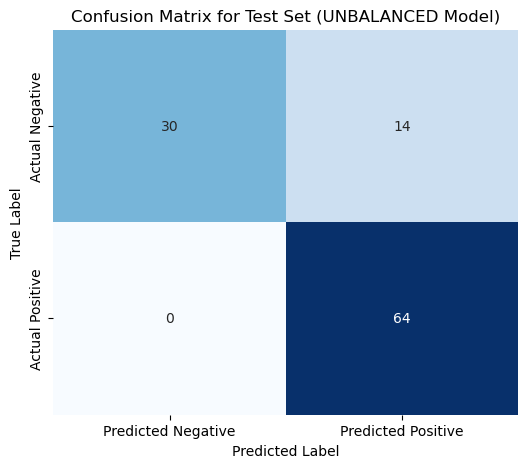


UNBALANCED model's test set evaluation complete. Results are stored in 'unbalanced_test_results' dictionary.


In [15]:
def evaluate_model(model, dataloader, criterion, device, phase="Test"):
    """
    Evaluates the model on the given DataLoader and computes various metrics.
    Args:
        model (torch.nn.Module): The trained model to evaluate.
        dataloader (DataLoader): DataLoader for the dataset to evaluate (e.g., test_loader).
        criterion (torch.nn.Module): The loss function.
        device (torch.device): The device (CPU or CUDA) to use for evaluation.
        phase (str): The name of the evaluation phase (e.g., "Test", "Validation").
    Returns:
        dict: A dictionary containing computed loss, accuracy, precision, recall, and F1-score.
    """
    model.eval()  # Definir modo de avaliação
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []
    
    print(f"\nStarting {phase} set evaluation...")
    with torch.no_grad():  
        for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            # para BCEWithLogitsLoss, labels devem ser (batch_size, 1)
            if labels.dim() == 1:
                labels = labels.unsqueeze(1)
            loss = criterion(outputs, labels)
            
            # Coverte logits para probabilidades e depois para predicoes binarias
            preds_proba = torch.sigmoid(outputs)
            binary_preds = (preds_proba > 0.5).float() # Threshold 0.5
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(binary_preds == labels.data)
            
            all_preds.extend(binary_preds.view(-1).cpu().numpy())
            all_labels.extend(labels.view(-1).cpu().numpy())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc_tensor = running_corrects.double() / len(dataloader.dataset)
    
    # Calular metricas usando sklearn
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)
    
    test_accuracy = accuracy_score(all_labels_np, all_preds_np)
    test_precision = precision_score(all_labels_np, all_preds_np, zero_division=0)
    test_recall = recall_score(all_labels_np, all_preds_np, zero_division=0)
    test_f1 = f1_score(all_labels_np, all_preds_np, zero_division=0)
    
    # Calcular Matriz de Confusão
    cm = confusion_matrix(all_labels_np, all_preds_np)
    
    print(f"\n--- {phase} Set Results ---")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy (Tensor): {epoch_acc_tensor:.4f}")
    print(f"Accuracy (Sklearn): {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1-Score: {test_f1:.4f}")
    print("--------------------------")
    
    # Plotar Matriz de Confusão
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {phase} Set (UNBALANCED Model)')
    plt.show()
    
    return {
        'loss': epoch_loss,
        'accuracy_tensor': epoch_acc_tensor.item(),
        'accuracy_sklearn': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'confusion_matrix': cm
    }

# --- MODIFIED: Execute evaluation on the UNBALANCED model ---
# We use the 'final_unbalanced_model' variable from the previous step
# And save the results to a new variable 'unbalanced_test_results'
print("Evaluating the UNBALANCED model on the test set...")
unbalanced_test_results = evaluate_model(
    final_unbalanced_model,  # Using the correct model
    test_loader, 
    criterion, 
    device, 
    phase="Test"
)

print("\nUNBALANCED model's test set evaluation complete. Results are stored in 'unbalanced_test_results' dictionary.")

Displaying 5 random images with predictions from the UNBALANCED model:
------------------------------------------------------------


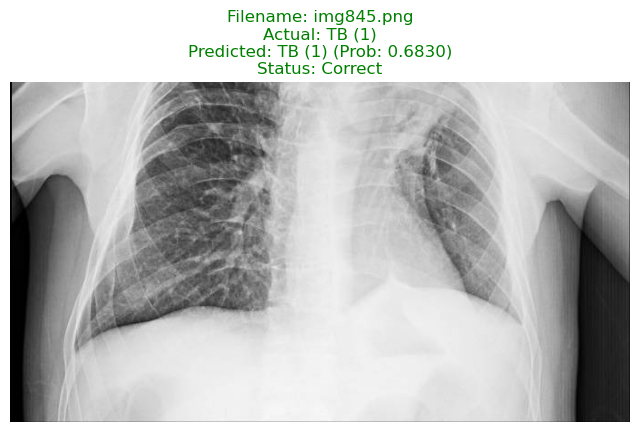

------------------------------------------------------------


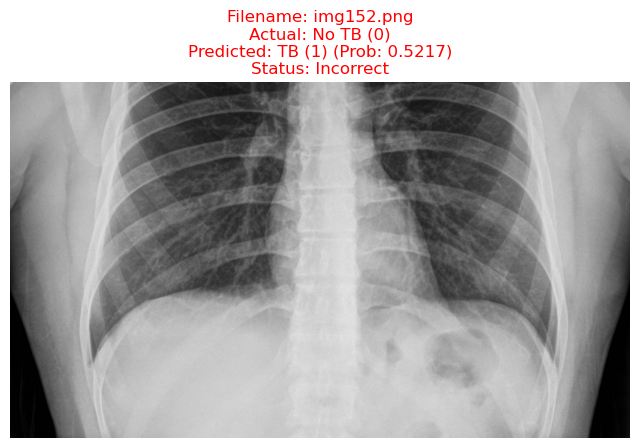

------------------------------------------------------------


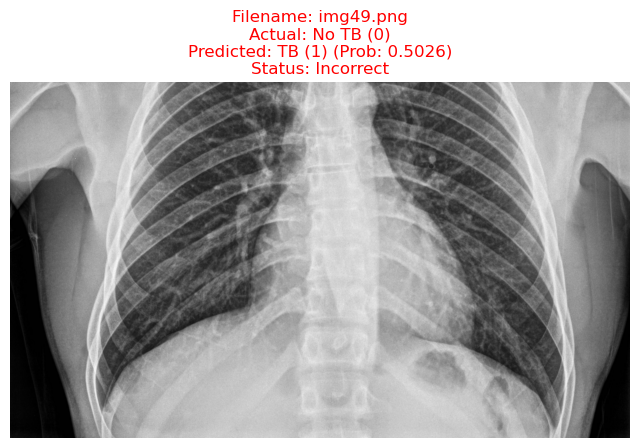

------------------------------------------------------------


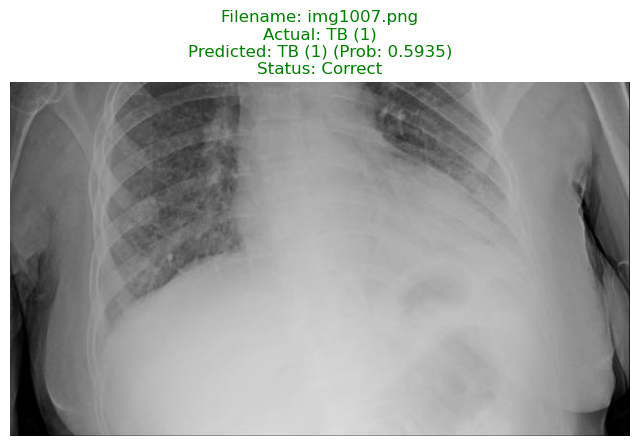

------------------------------------------------------------


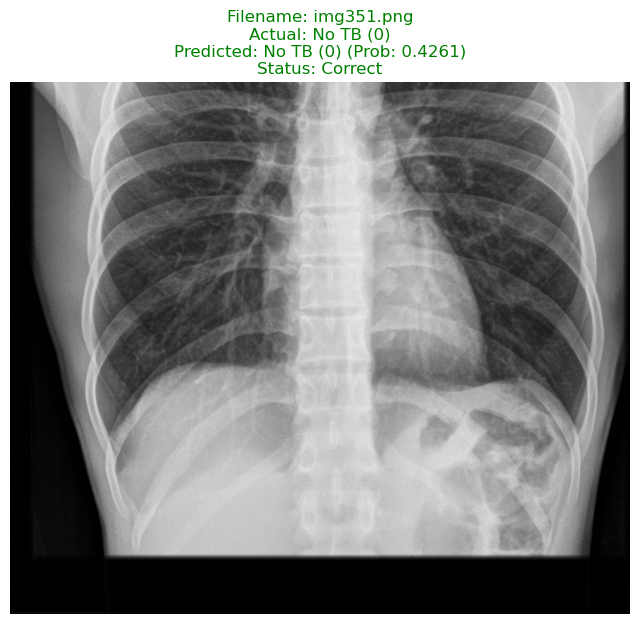

------------------------------------------------------------


In [16]:
# --- MODIFIED: Use the UNBALANCED model for making predictions ---

# Set the UNBALANCED model to evaluation mode
final_unbalanced_model.eval() 

# Função auxiliar para converter logit para label (No change needed)
def get_label_name(label_value):
    return "TB" if label_value == 1 else "No TB"

def display_predictions(num_images=5):
    """
    Loads random images from the test set, makes predictions using the UNBALANCED model, 
    and displays them alongside the actual label and model's prediction.
    """
    if len(test_df) == 0:
        print("Test DataFrame is empty. Cannot display predictions.")
        return
    
    # Updated print statement for clarity
    print(f"Displaying {min(num_images, len(test_df))} random images with predictions from the UNBALANCED model:")
    print("-" * 60)
    
    # Converter test_df para uma lista de dict 
    test_samples = test_df.to_dict('records')
    
    # Selecionar indices aleatorios
    if len(test_samples) > num_images:
        selected_samples = random.sample(test_samples, num_images)
    else:
        selected_samples = test_samples
        
    for i, sample in enumerate(selected_samples):
        img_path = sample['path']
        true_label = sample['is_tb']
        filename = os.path.basename(img_path)
        
        try:
            # Carregar imagem original (display)
            original_image = Image.open(img_path).convert('RGB')
            
            # Aplicar transformacoes para entrada do modelo
            input_tensor = val_test_transforms(original_image)
            input_batch = input_tensor.unsqueeze(0) # Adicionar dimensao de batch
            
            # Mover input para dispositivo
            input_batch = input_batch.to(device)
            
            # Predição using the UNBALANCED model
            with torch.no_grad():
                # --- MODIFICATION: Use 'final_unbalanced_model' ---
                output_logits = final_unbalanced_model(input_batch)
                
                prediction_proba = torch.sigmoid(output_logits).item()
                predicted_label = 1 if prediction_proba > 0.5 else 0
                
            # Determina se acertou
            is_correct = (predicted_label == true_label)
            status_text = "Correct" if is_correct else "Incorrect"
            status_color = "green" if is_correct else "red"
            
            # Mostrar imagem
            plt.figure(figsize=(8, 7)) 
            plt.imshow(original_image)
            plt.axis('off')
            
            title_text = (
                f"Filename: {filename}\n"
                f"Actual: {get_label_name(true_label)} ({true_label})\n"
                f"Predicted: {get_label_name(predicted_label)} ({predicted_label}) (Prob: {prediction_proba:.4f})\n"
                f"Status: {status_text}"
            )
            plt.title(title_text, color=status_color)
            plt.show()
            print("-" * 60) # Separador para proxima imagem
            
        except Exception as e:
            print(f"Error processing image {filename} at path {img_path}: {e}")
            print("-" * 60)

# Call the function to display predictions
display_predictions(num_images=5)